In [ ]:
   conda create -n tf_env python=3.8
   conda activate tf_env
   conda install tensorflow
   

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


In [7]:

os.getcwd()


'C:\\Users\\Saikumar\\Smart-Energy-Consumption-Forecasting'

In [8]:

os.listdir()


['.git',
 '.gitignore',
 '.ipynb_checkpoints',
 'anaconda_projects',
 'Data Collection & Understanding.ipynb',
 'final_feature_engineered_data.csv',
 'hourly_cleaned_energy.csv',
 'module7_energy_analytics_dashboard_recommendation_engine.ipynb',
 'Module_2_Data_Cleaning.ipynb',
 'Module_3_Feature_Engineering.ipynb',
 'Module_4_Linear_Regression.ipynb',
 'Module_5_LSTM_Energy_Forecasting.ipynb',
 'Module_6_Model_Evaluation_Comparison.ipynb',
 'smart_home_energy_consumption_large.csv']

In [9]:
df = pd.read_csv("hourly_cleaned_energy.csv")
df.head()


,Timestamp,Energy_kWh,Energy_Scaled
0,2023-01-01 00:00:00,11.48,0.297095
1,2023-01-01 01:00:00,17.92,0.475242
2,2023-01-01 02:00:00,26.27,0.706224
3,2023-01-01 03:00:00,12.16,0.315906
4,2023-01-01 04:00:00,15.61,0.411342


In [10]:
df.columns


Index(['Timestamp', 'Energy_kWh', 'Energy_Scaled'], dtype='object')

In [12]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('Timestamp', inplace=True)

df.head()


,Energy_kWh,Energy_Scaled
Timestamp,,
2023-01-01 00:00:00,11.48,0.297095
2023-01-01 01:00:00,17.92,0.475242
2023-01-01 02:00:00,26.27,0.706224
2023-01-01 03:00:00,12.16,0.315906
2023-01-01 04:00:00,15.61,0.411342


In [14]:
energy_col = "Energy_kWh"


In [15]:
df[energy_col].head()


Timestamp
2023-01-01 00:00:00    11.48
2023-01-01 01:00:00    17.92
2023-01-01 02:00:00    26.27
2023-01-01 03:00:00    12.16
2023-01-01 04:00:00    15.61
Name: Energy_kWh, dtype: float64

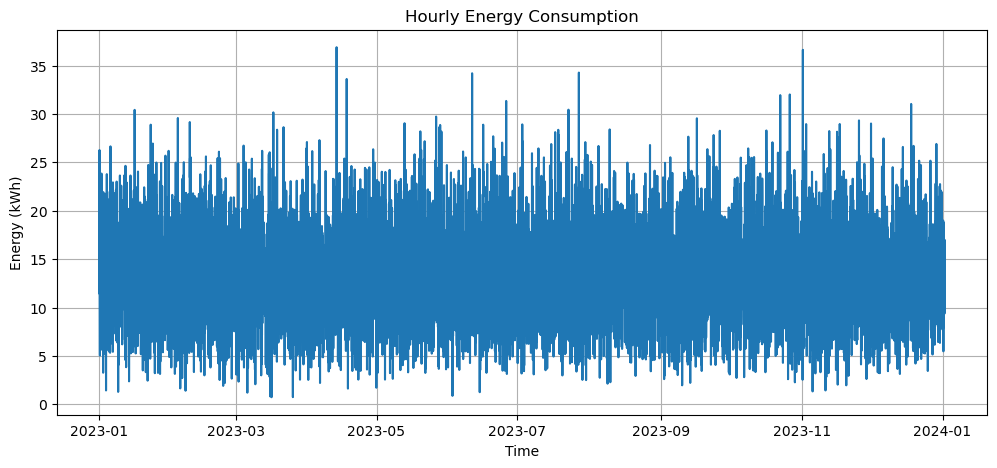

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df.index, df[energy_col])
plt.title("Hourly Energy Consumption")
plt.xlabel("Time")
plt.ylabel("Energy (kWh)")
plt.grid(True)
plt.show()


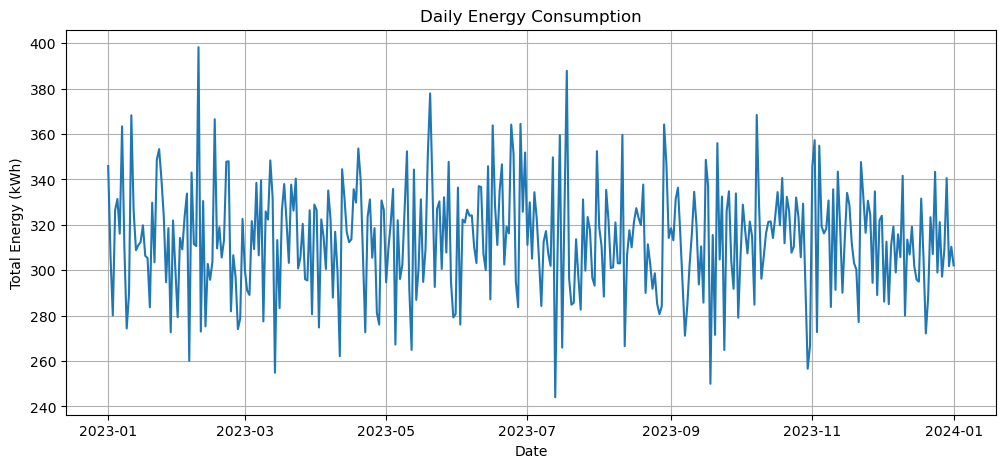

In [17]:
daily_energy = df[energy_col].resample("D").sum()

plt.figure(figsize=(12,5))
plt.plot(daily_energy.index, daily_energy.values)
plt.title("Daily Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Total Energy (kWh)")
plt.grid(True)
plt.show()


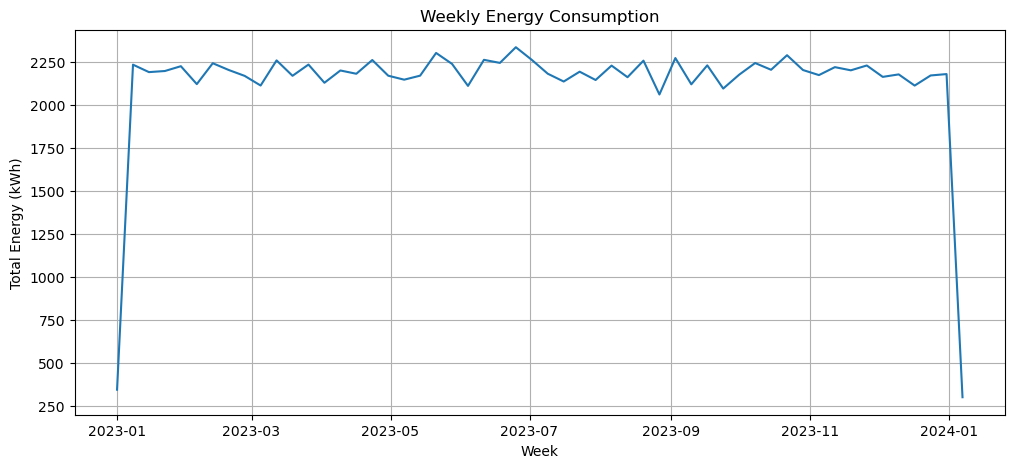

In [18]:
weekly_energy = df[energy_col].resample("W").sum()

plt.figure(figsize=(12,5))
plt.plot(weekly_energy.index, weekly_energy.values)
plt.title("Weekly Energy Consumption")
plt.xlabel("Week")
plt.ylabel("Total Energy (kWh)")
plt.grid(True)
plt.show()


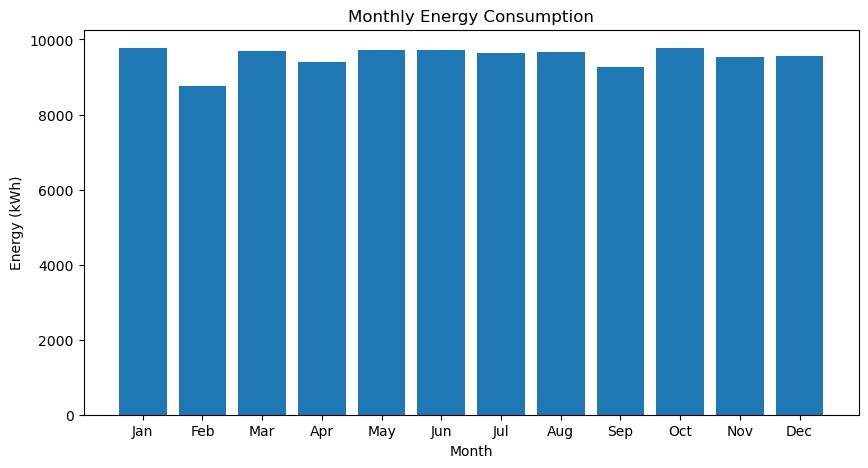

In [24]:
monthly_energy = df[energy_col].resample("ME").sum()

plt.figure(figsize=(10,5))
plt.bar(monthly_energy.index.strftime("%b"), monthly_energy.values)
plt.title("Monthly Energy Consumption")
plt.xlabel("Month")
plt.ylabel("Energy (kWh)")
plt.show()


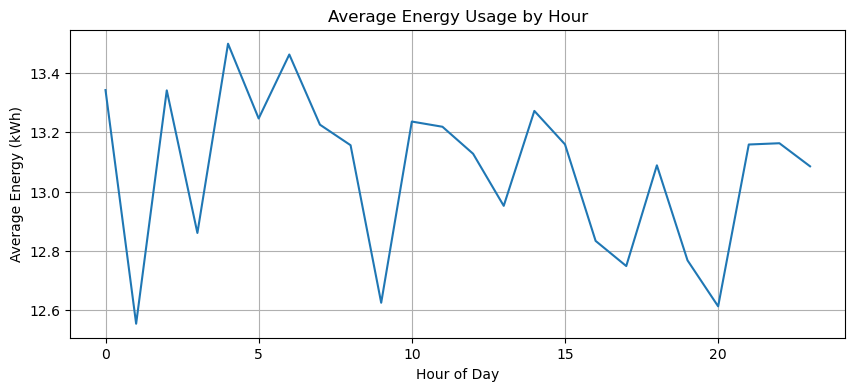

In [20]:
df["hour"] = df.index.hour
hourly_avg = df.groupby("hour")[energy_col].mean()

plt.figure(figsize=(10,4))
plt.plot(hourly_avg.index, hourly_avg.values)
plt.title("Average Energy Usage by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Energy (kWh)")
plt.grid(True)
plt.show()


In [25]:
suggestions = []

peak_hour = hourly_avg.idxmax()
suggestions.append(
    f"Peak energy usage occurs around {peak_hour}:00 hrs. Consider shifting non-essential usage to off-peak hours."
)

if monthly_energy.iloc[-1] > monthly_energy.mean():
    suggestions.append(
        "Recent monthly energy consumption is higher than average. Energy optimization is recommended."
    )


In [26]:
print("SMART ENERGY SAVING SUGGESTIONS:\n")

for i, s in enumerate(suggestions, 1):
    print(f"{i}. {s}")


SMART ENERGY SAVING SUGGESTIONS:

1. Peak energy usage occurs around 4:00 hrs. Consider shifting non-essential usage to off-peak hours.


In [27]:
dashboard_summary = pd.DataFrame({
    "Metric": [
        "Total Energy Consumption (kWh)",
        "Average Daily Energy (kWh)",
        "Peak Usage Hour"
    ],
    "Value": [
        df[energy_col].sum(),
        daily_energy.mean(),
        f"{peak_hour}:00 hrs"
    ]
})

dashboard_summary


,Metric,Value
0,Total Energy Consumption (kWh),114831.21
1,Average Daily Energy (kWh),313.746475
2,Peak Usage Hour,4:00 hrs
